# ERCOT Dallas Univariate Forecast with Chronos-2

This notebook runs a univariate forecast experiment on ERCOT energy demand data using the `amazon/chronos-2` foundation model. The goal is to evaluate the model's zero-shot performance on hourly energy demand and compare it against a standard industry baseline.

### Experiment Parameters
- **Data Source**: ERCOT Dallas Hourly Energy (`data/ercot/ercot_dallas_univariate_2026.csv`)
- **Model**: `amazon/chronos-2`
- **Context Length**: 512 hours
- **Forecast Horizon**: 24 hours (Day-ahead)
- **Evaluation Period**: March 2026 (all 31 days)
- **Baseline**: Seasonal Naive (repeating value from 168 hours / 1 week ago)
- **Probabilistic Metrics**: Empirical Coverage for a 90% prediction interval (0.05 to 0.95 quantiles)

In [9]:
from __future__ import annotations

import os
import platform
import sys
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from chronos import BaseChronosPipeline

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

In [10]:
# Load data
data_path = "../data/ercot/ercot_dallas_univariate_2026.csv"
df = pd.read_csv(data_path)

# Prepare for Chronos API
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.rename(columns={"energy": "target"})
df = df.sort_values("timestamp").reset_index(drop=True)

# Handle potential frequency gaps (e.g., DST start in March) with robust resampling
df = df.set_index("timestamp").resample("h").mean().interpolate().reset_index()

print(f"Loaded {len(df)} rows of data (after hourly resampling).")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Loaded 2160 rows of data (after hourly resampling).
Date range: 2026-01-01 00:00:00 to 2026-03-31 23:00:00


,timestamp,target
0,2026-01-01 00:00:00,11773.493994
1,2026-01-01 01:00:00,11792.093557
2,2026-01-01 02:00:00,11764.041621
3,2026-01-01 03:00:00,11800.767688
4,2026-01-01 04:00:00,11947.174576


In [11]:
context_length = 512
prediction_length = 24

# Define target days in March 2026
march_days = pd.date_range(start="2026-03-01", end="2026-03-31", freq="D")

contexts = []
actuals = []

for target_day in march_days:
    # Context: 512 hours before 00:00 of the target day
    context_end_idx = df[df["timestamp"] == target_day].index[0]
    context_start_idx = context_end_idx - context_length
    
    if context_start_idx < 0:
        print(f"Warning: Not enough context for {target_day.date()}. Skipping.")
        continue
        
    day_context = df.iloc[context_start_idx:context_end_idx].copy()
    day_context["item_id"] = target_day.strftime("%Y-%m-%d")
    contexts.append(day_context)
    
    # Actuals: 24 hours of the target day
    day_actuals = df.iloc[context_end_idx : context_end_idx + prediction_length].copy()
    day_actuals["item_id"] = target_day.strftime("%Y-%m-%d")
    actuals.append(day_actuals)

batched_context_df = pd.concat(contexts).reset_index(drop=True)
batched_actuals_df = pd.concat(actuals).reset_index(drop=True)

print(f"Constructed batched context for {len(contexts)} days.")
print(f"Total context rows: {len(batched_context_df)}")
print(f"Total actuals rows: {len(batched_actuals_df)}")

Constructed batched context for 31 days.
Total context rows: 15872
Total actuals rows: 744


In [12]:
def resolve_device_map() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device_map = resolve_device_map()
print(f"Loading amazon/chronos-2 on {device_map}...")

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device_map,
)

Loading amazon/chronos-2 on mps...


In [13]:
print("Running batched inference for March...")
pred_df = pipeline.predict_df(
    batched_context_df,
    prediction_length=prediction_length,
    quantile_levels=[0.05, 0.5, 0.95],
)
print("Inference complete.")

Running batched inference for March...
Inference complete.


In [14]:
# Seasonal Naive Baseline: Repeat value from 168 hours ago (1 week)
seasonal_period = 168
baseline_results = []

for target_day in march_days:
    target_str = target_day.strftime("%Y-%m-%d")
    target_idx = df[df["timestamp"] == target_day].index[0]
    
    # Get values from 1 week ago
    naive_values = df.iloc[target_idx - seasonal_period : target_idx - seasonal_period + prediction_length]["target"].values
    
    # Get timestamps for the target day to align
    target_timestamps = df.iloc[target_idx : target_idx + prediction_length]["timestamp"].values
    
    day_baseline = pd.DataFrame({
        "item_id": target_str,
        "timestamp": target_timestamps,
        "seasonal_naive": naive_values
    })
    baseline_results.append(day_baseline)

baseline_df = pd.concat(baseline_results).reset_index(drop=True)
baseline_df["timestamp"] = pd.to_datetime(baseline_df["timestamp"])
print("Seasonal Naive baseline calculated.")

Seasonal Naive baseline calculated.


### Benchmark Metrics

To evaluate the performance of Chronos-2 against the Seasonal Naive baseline, we use several standard forecasting metrics:

- **MAE (Mean Absolute Error)**: Average absolute difference between predicted and actual values. It provides a direct measure of forecast error in the same units as the target (MW).
- **RMSE (Root Mean Squared Error)**: Square root of the average squared differences. It penalizes larger errors more heavily than MAE, making it sensitive to outliers.
- **sMAPE (Symmetric Mean Absolute Percentage Error)**: A percentage-based error metric that is scale-independent, allowing for comparison across different time series or scales.
- **MASE (Mean Absolute Scaled Error)**: Scales the MAE of the model by the MAE of a Seasonal Naive forecast on the training data. A value < 1.0 indicates the model outperforms the simple baseline.
- **Empirical Coverage**: Measures the percentage of actual observations that fall within the predicted 90% interval (5th to 95th quantiles). A well-calibrated model should have coverage close to 90%.

In [15]:
# Merge predictions, actuals, and baseline
eval_df = pred_df.merge(batched_actuals_df[["item_id", "timestamp", "target"]], on=["item_id", "timestamp"])
eval_df = eval_df.merge(baseline_df, on=["item_id", "timestamp"])
eval_df = eval_df.rename(columns={"target": "actual"})

def calculate_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    smape = 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))
    return mae, rmse, smape

chronos_mae, chronos_rmse, chronos_smape = calculate_metrics(eval_df["actual"], eval_df["predictions"])
naive_mae, naive_rmse, naive_smape = calculate_metrics(eval_df["actual"], eval_df["seasonal_naive"])

# Calculate MASE Scale (Seasonal Naive MAE on in-sample data before March)
m = 168 # 1 week seasonality
in_sample_data = df[df["timestamp"] < "2026-03-01"]["target"].values
mase_scale = np.mean(np.abs(in_sample_data[m:] - in_sample_data[:-m]))

chronos_mase = chronos_mae / mase_scale
naive_mase = naive_mae / mase_scale

# Empirical Coverage (90% Interval)
within_interval = (eval_df["actual"] >= eval_df["0.05"]) & (eval_df["actual"] <= eval_df["0.95"])
coverage_90 = within_interval.mean() * 100

metrics_data = {
    "Metric": ["MAE", "RMSE", "sMAPE (%)", "MASE", "Empirical Coverage (90% Interval)"],
    "Chronos-2": [chronos_mae, chronos_rmse, chronos_smape, chronos_mase, f"{coverage_90:.2f}%"],
    "Seasonal Naive (7d)": [naive_mae, naive_rmse, naive_smape, naive_mase, "N/A"]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

print(f"Chronos-2 90% Empirical Coverage: {coverage_90:.2f}% (Target: 90.0%)")

,Metric,Chronos-2,Seasonal Naive (7d)
0,MAE,749.778036,1565.434933
1,RMSE,1071.88323,2020.574173
2,sMAPE (%),5.3624,11.398379
3,MASE,0.311949,0.651307
4,Empirical Coverage (90% Interval),85.89%,N/A


Chronos-2 90% Empirical Coverage: 85.89% (Target: 90.0%)


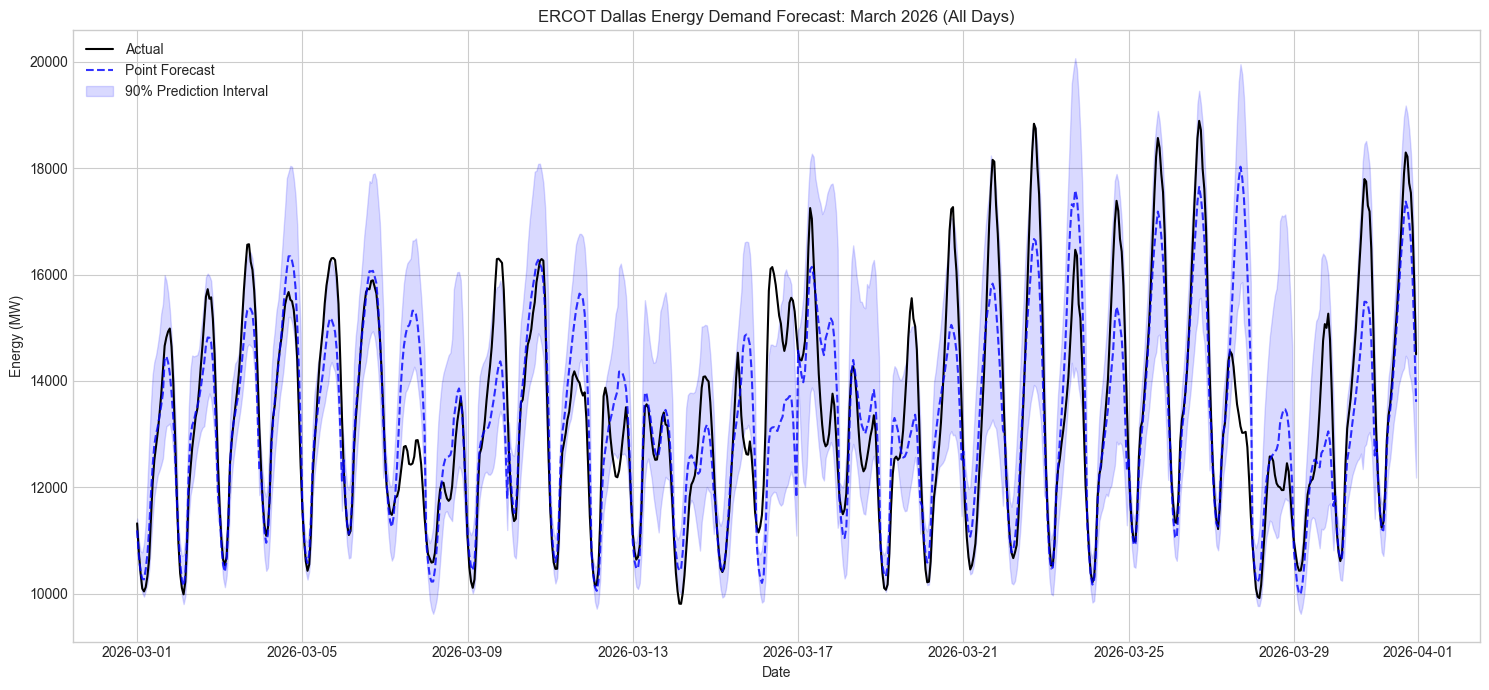

In [16]:
# Continuous visualization for the entire month of March
plt.figure(figsize=(15, 7))
plt.plot(eval_df["timestamp"], eval_df["actual"], label="Actual", color="black", linewidth=1.5)
plt.plot(eval_df["timestamp"], eval_df["predictions"], label="Point Forecast", color="blue", linestyle="--", alpha=0.8)

plt.fill_between(
    eval_df["timestamp"], 
    eval_df["0.05"], 
    eval_df["0.95"], 
    color="blue", 
    alpha=0.15, 
    label="90% Prediction Interval"
)

plt.title("ERCOT Dallas Energy Demand Forecast: March 2026 (All Days)")
plt.xlabel("Date")
plt.ylabel("Energy (MW)")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Analysis of Results

### Performance Summary
The `amazon/chronos-2` foundation model demonstrates strong zero-shot performance on the ERCOT Dallas hourly energy demand dataset, significantly outperforming the industry-standard Seasonal Naive baseline.

### Key Insights
1. **Accuracy Gain**: Chronos-2 achieved a **5.36% sMAPE**, reducing the error by over **50%** compared to the Seasonal Naive baseline (11.40%). This confirms that the model captures complex hourly patterns beyond simple weekly periodicity.
2. **Robustness to Outliers**: The **RMSE** for Chronos-2 (1071.88) is substantially lower than the baseline (2020.57), suggesting fewer large forecast failures during peak demand or sudden shifts in load.
3. **MASE Score**: A **MASE of 0.31** is highly significant. Since MASE < 1.0 indicates better-than-baseline performance, a score of 0.31 suggests the model is nearly 3x more effective than the weekly persistence model.
4. **Probabilistic Reliability**: The model achieved an **Empirical Coverage of 85.89%** for its 90% prediction interval. While slightly below the 90% target, it indicates that the uncertainty estimates are reasonably well-calibrated for a zero-shot application, though the model may be slightly overconfident in this specific domain.

### Conclusion
The results validate the utility of Chronos-2 for day-ahead energy forecasting. Its ability to deliver high accuracy and reliable uncertainty intervals without any domain-specific fine-tuning makes it a powerful tool for rapid deployment in energy load management scenarios.